# Detrending light curves with AltaiPony

De-trending [dɪ.tɹˈɛndɪŋ] of lightcurves denotes the removal of instrumental or some physical trends in order to improve the analysis of other physical trends, in our case, flares. Flaring stars show variability on different timescales, with flares typically being a very fast variation. That allows us to separate it from the *usually* slower star-spot induced variability, even if the latter has a higher amplitude. 

In this tutorial, we will go through the de-trending pipeline in AltaiPony, including a Savitzky-Golay filter-based de-trending and a more involved custom detrening method tailored toward removing heavy spot variability from very active stars while preserving the flare signal. In the end, you will also learn how to use your own detrending function within AltaiPony.

In [13]:
import lightkurve as lk

from altaipony.customdetrend import custom_detrending
from altaipony.lcio import to_flare_lightcurve

import matplotlib.pyplot as plt

Let's start grabbing a TESS light curve of TIC 29780677, a young, active star, observed with TESS with ``search_lightkurve``:

In [14]:
# get a table of light curves from MAST
lc_table = lk.search_lightcurve("TIC 29780677", sector=2, exptime=120, mission="TESS", author="SPOC")

lc_table

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,29780677,0.0


Let download the lightcurve:

2% (399/18699) of the cadences will be ignored due to the quality mask (quality_bitmask=175).
2% (399/18699) of the cadences will be ignored due to the quality mask (quality_bitmask=175).


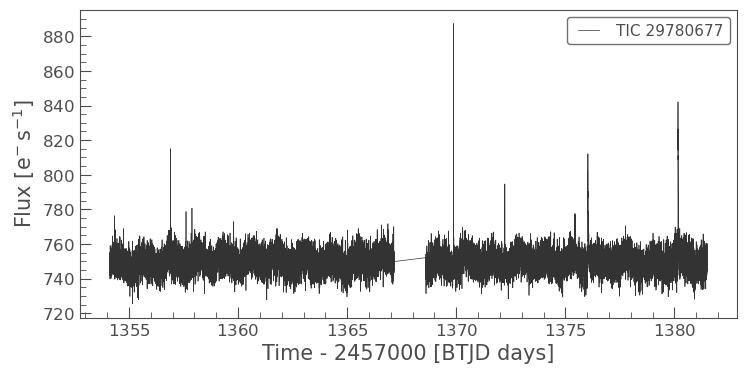

In [15]:
%matplotlib inline
lc = lc_table[0].download()
lc.plot();

Just like in the Quickstart tutorial, this light curve also shows flares. Now let's make ``lc`` a FlareLightCurve object, and apply detrending:

In [16]:
def plot_detrending(flcd_savgol, offset=200):
    plt.figure(figsize=(10, 5))
    plt.plot(flcd_savgol.time.value, flcd_savgol.flux, label='Flux', alpha=0.5)
    plt.plot(flcd_savgol.time.value, flcd_savgol.detrended_flux+offset, label='Detrended flux', color='orange')
    plt.xlabel('Time')
    plt.ylabel('Flux')
    plt.title('Sav-Gol Detrending of Flare Light Curve')
    plt.legend()
    
flc = to_flare_lightcurve(lc)
flcd_savgol = flc.detrend("savgol")



In [17]:
savgol_flares = flcd_savgol.find_flares().flares
savgol_flares.sort_values(by="ed_rec", ascending=False)

Found 0 candidate(s) in the (0,9226) gap.
Found 4 candidate(s) in the (9226,18300) gap.


,istart,istop,cstart,cstop,tstart,tstop,ed_rec,ed_rec_err,ampl_rec,dur,total_n_valid_data_points
2,14483,14515,106969,107003,1376.024391,1376.071613,219.18996245271228,4.981281880878935,0.09875842246991295,0.047222,18300.0
3,17372,17389,109949,109966,1380.163246,1380.186856,154.39942826375338,3.812846344495266,0.12777411011580764,0.023611,18300.0
0,10142,10147,102541,102546,1369.874426,1369.881370,40.938383537746944,1.5526117544866778,0.19132941549563598,0.006944,18300.0
1,11802,11805,104234,104237,1372.225803,1372.229970,14.995209041935974,1.4470004230492177,0.0684719384728012,0.004167,18300.0


There are three main parameters to play with: ``w`` (default=121), ``max_sigma``(defaul=2.5), and ``longdecay``(default=6).

``w`` is the length of the Sav-Gol filter. Larger window means lower frequency pass, filtering out modulation on lower timescales. 

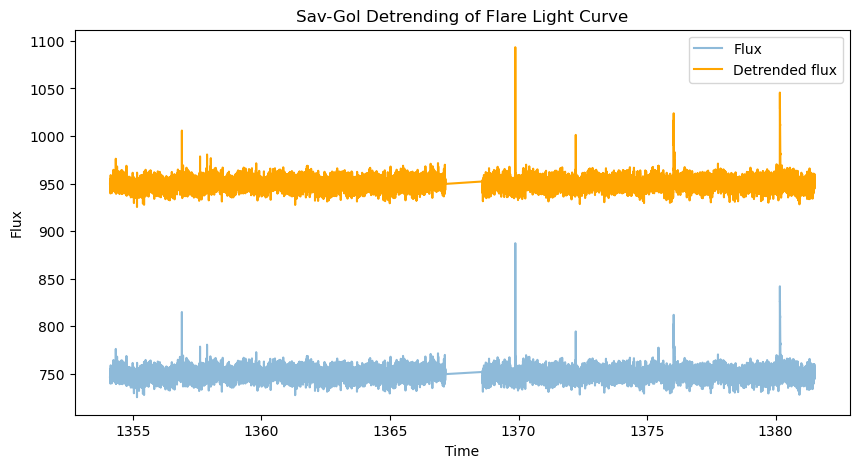

In [18]:
flcd_savgol2 = flc.detrend("savgol", w=10001)
plot_detrending(flcd_savgol2)

Too small ``w`` can approach the timescales of the flares themselves, distorting them, especially if the flare is not fully masked, which can happen if ``max_sigma`` is set too high:

Larger ``max_sigma`` filters out fewer flare points before applying the filter, leading to a worse detrending around long-duration flares. On the other hand, too low ``max_sigma`` preserved more noise in the detrended data:

(1356.7, 1357.7)

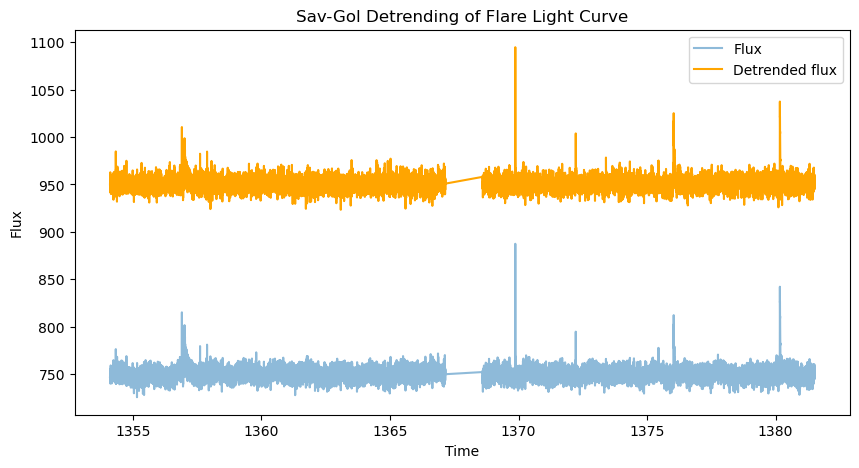

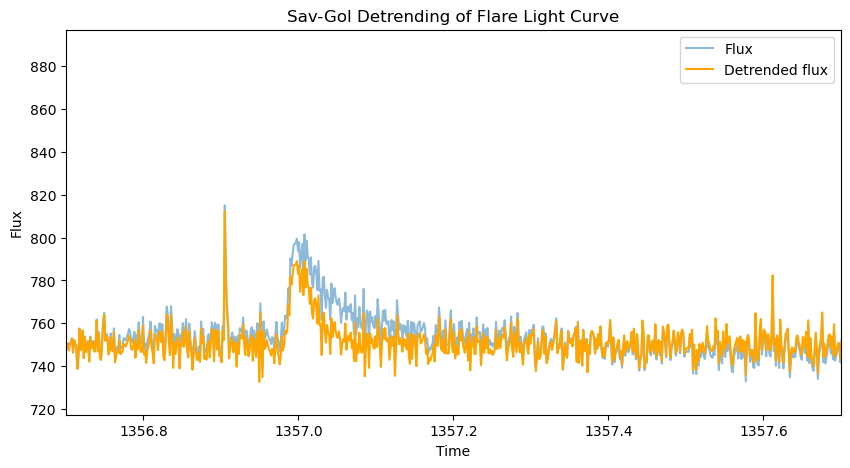

In [19]:
from altaipony.fakeflares import flare_model_mendoza2022
import astropy.units as u
flcl = flc.copy()
t = flcl.time.value
long_duration_flare = flare_model_mendoza2022(t, tpeak=1357.0, ampl=50, fwhm=.04)
flcl.flux += long_duration_flare * u.electron / u.second


# too low max_sigma preserves noise
flcd_savgol3 = flcl.detrend("savgol", max_sigma=1.5)
plot_detrending(flcd_savgol3, offset=200)

# too high max_sigma exposes long-duration flares to filtering
flcd_savgol4 = flcl.detrend("savgol", max_sigma=30)
plot_detrending(flcd_savgol4, offset=0)
plt.xlim(1356.7, 1357.7)

Finally, the ``longdecay`` parameter. The sigma-clipping pipeline running under the hood of the Sav-Gol de-trender will expand the filtering mask around the outliers by $\sqrt{\text{length of the outliers series}}$. If longdecay=1, this completes the mask expansion. If longdecay=2, the tail of the series of outliers is expanded twice, thrice for longdecay=3, and so on.

Below, we can see how keeping the longdecay parameter too short exposes the flare tail to the Sav-Gol filter. Making it too long on the other hand, prevents the filter from de-trending accurately in the area (not shown).

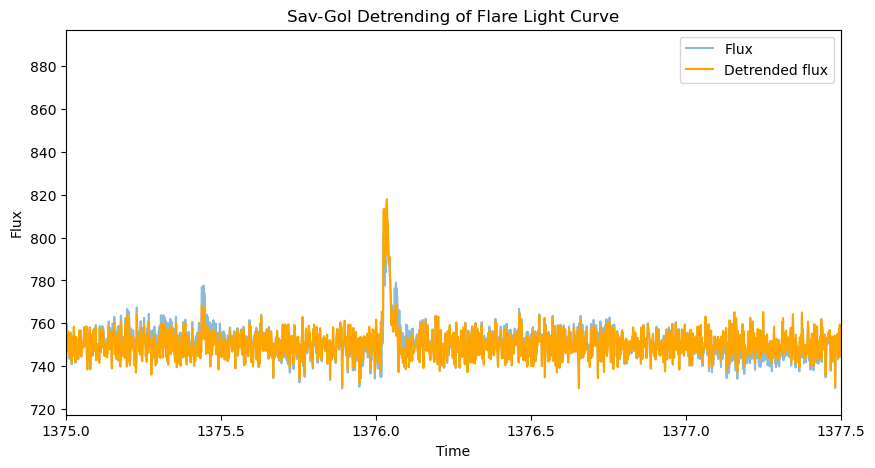

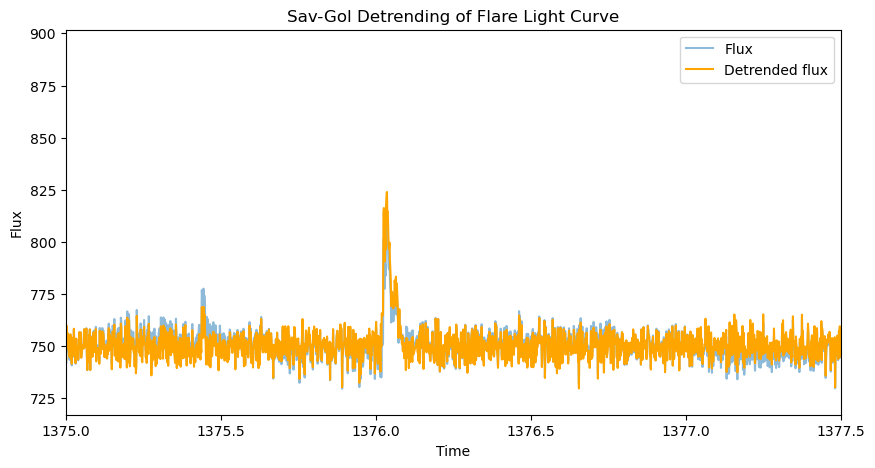

In [20]:
flcd_savgol5 = flcl.detrend("savgol", longdecay=1)
plot_detrending(flcd_savgol5, offset=0)
plt.xlim(1375, 1377.5)

flcd_savgol6 = flcl.detrend("savgol", longdecay=6)
plot_detrending(flcd_savgol6, offset=0)
plt.xlim(1375, 1377.5);

The Savitzky-Golay filter works well on light curves like the one above, where there is low-amplitude variability on a time scale much shorter than the light curve, but longer than the flare. However, oftentimes spot variability occurs on timescale close to the light curve length (especially for the shorter TESS light curves). For this, the ``custom`` detrending add a spline fit with an variable time step between 5h and 15h, as a first step in the analysis, and follows it up by two Sav-Gol detrending iterations to remove variability on 6h and 3h timescales. 

To see what that means, let's try a different light curve:

0% (31/16812) of the cadences will be ignored due to the quality mask (quality_bitmask=175).
0% (31/16812) of the cadences will be ignored due to the quality mask (quality_bitmask=175).


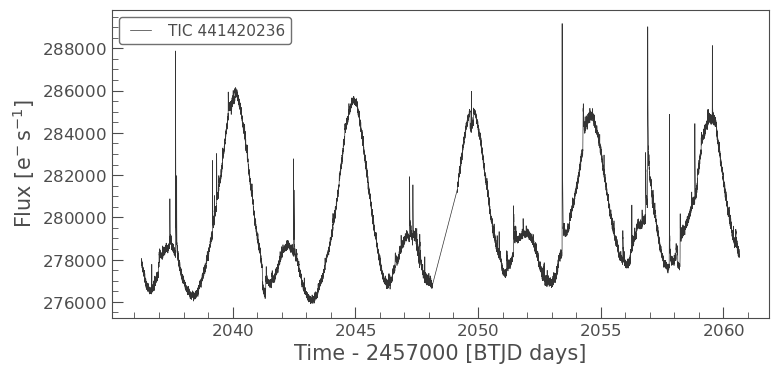

In [21]:
# get a table of light curves from MAST
lc = lk.search_lightcurve('AU Mic', mission='TESS', author='SPOC', exptime=120, sector=27)[0].download()

lc.plot();

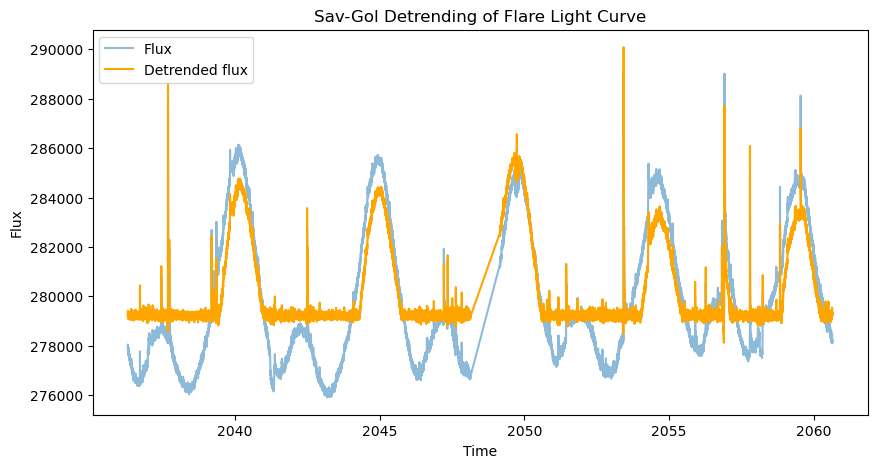

In [22]:
flc = to_flare_lightcurve(lc)
flcd_savgol_aumic = flc.detrend("savgol")
plot_detrending(flcd_savgol_aumic)

The filter clearly missed the longer-duration arc of the spot modulation. This calls for an additional step to remove the large-amplitude variability, cue the custom detrending method:

## Custom De-trending with AltaiPony

The custom de-trending method implemented in AltaiPony combines a flexible spline fit with two Savitzky-Golay iterations, which successively separate fast flare signal from slow(er) rotational modulation. The parameters from the Savitzky-Golay detrender can be passed to those two iterations. The spline fit iterates over different coarseness parameters, and spline orders, and penalizes the lack of positive outliers to avoid splining away flares by accident:

Spline detrending params: {'coarseness': 15, 'order': 2, 'phase': 0, 'score': 1592.6390569822922}


/home/ilin/anaconda3/envs/altaidev/lib/python3.12/site-packages/altaipony/altai.py:385: RuntimeWarning: All-NaN slice encountered
  it_med = np.full_like(detrended_flux, np.nanmedian(detrended_flux))
/home/ilin/anaconda3/envs/altaidev/lib/python3.12/site-packages/altaipony/altai.py:392: RuntimeWarning: All-NaN slice encountered
  it_med[:] = np.nanmedian(good_flux)


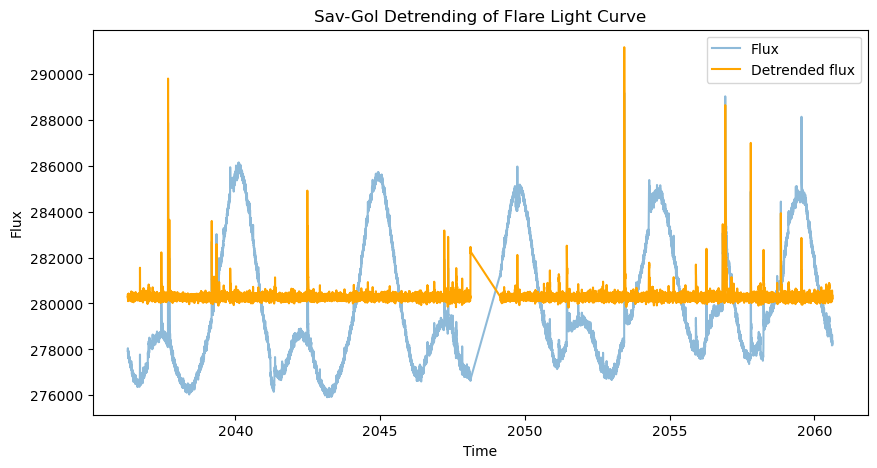

In [23]:
flcd_custom_aumic = flc.detrend("custom", func=custom_detrending)
plot_detrending(flcd_custom_aumic)
# plt.xlim(2050,2055)

Much better than just Sav-Gol!

Note how the de-trending can still distort large or long-duration flares (e.g., around t=2053.5d). This does not prevent them from being detected, but the flare energy estimated will be biased as a result and smaller flares in their vicinity might be missed. Therefore, ``fit_flares()`` fits a flare around the event's region, which both catches additional smaller flares by fitting several flare templates and finding the best-fit result, and calculates a polynomial baseline around the already detected event (see Getting Started tutorial). 

### You own de-trending function

Note also the syntax of the de-trending call above. You can pass *any* detrending function if you use the keyword "custom". Make sure that the function returns a ``FlareLightCurve`` object, and that the output is stored as ``detrended_flux``, ``detrended_flux_err`` keywords to pass the result to the flare finder.